In [1]:
#import dependencies
import nibabel as nib
import nilearn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
from nilearn import image, plotting
from nilearn.plotting import plot_roi
from nilearn.masking import apply_mask, unmask
import os

In [2]:
#load all runs for one subject (3). They first need to be downloaded from bash using the 'datalad get function'
bold_path = '/home/jovyan/studyforrest-data-aligned/sub-03/in_bold3Tp2'

runs = {}

for i in range(1, 9):
    filename = f'{bold_path}/sub-03_task-avmovie_run-{i}_bold.nii.gz'
    runs[f'run-{i}'] = nib.load(filename)

for run_name, img in runs.items(): #dimensions: x y z TRs (3d voxels x TRs)
    print(run_name, img.shape)

run-1 (64, 86, 45, 451)
run-2 (64, 86, 45, 441)
run-3 (64, 86, 45, 438)
run-4 (64, 86, 45, 488)
run-5 (64, 86, 45, 462)
run-6 (64, 86, 45, 439)
run-7 (64, 86, 45, 542)
run-8 (64, 86, 45, 338)


In [3]:
#load the brain and ROI masks for that subject
brain_path = 'studyforrest-data-aligned/src/tnt/sub-03/bold3Tp2/brain.nii.gz'
brain = nib.load(brain_path)

ROI_path = '/home/jovyan/studyforrest-data-visualrois/sub-03/rois'

rEBA = nib.load(ROI_path + "/rEBA_1_mask.nii.gz")
lEBA = nib.load(ROI_path + "/lEBA_2_mask.nii.gz")

brain_vox = brain.get_fdata()
rEBA_vox = rEBA.get_fdata()
lEBA_vox = lEBA.get_fdata() 

print(f"brain dimensions: {brain.shape}; total voxels: {np.sum(brain_vox> 0)}")
print(f"right EBA dimensions: {rEBA.shape}; total voxels: {np.sum(rEBA_vox> 0)}")
print(f"left EBA dimensions: {lEBA.shape}; total voxels: {np.sum(lEBA_vox> 0)}")


brain dimensions: (64, 86, 45); total voxels: 82673
right EBA dimensions: (64, 86, 45); total voxels: 92
left EBA dimensions: (64, 86, 45); total voxels: 45


/srv/conda/envs/notebook/lib/python3.10/site-packages/numpy/ma/core.py:2820: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


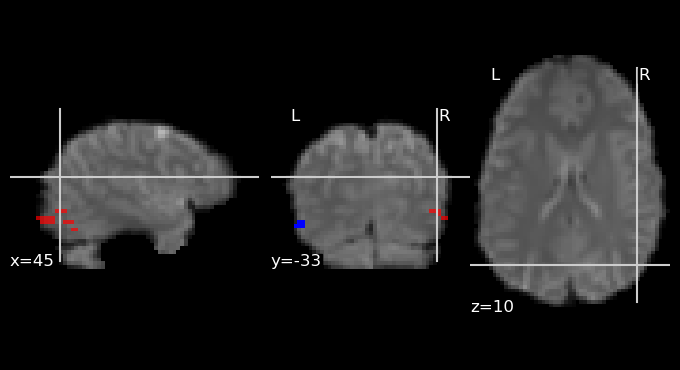

In [4]:
#plot the two ROIs to make sure they look correct (eyeballing)
solid_red = ListedColormap(['red'])
my_coordinates = (45, -33, 10)

display = plot_roi(rEBA, bg_img=brain, cmap=ListedColormap(['red']), colorbar=False, cut_coords = my_coordinates, display_mode = 'ortho')

# 2. Layer the second ROI on top
display.add_overlay(lEBA, cmap=ListedColormap(['blue']))

In [ ]:
#plot ROIs on top of the brain
#nilearn.plotting.view_img(rEBA, bg_img=brain, cut_coords=None, colorbar=True, title=None, threshold=1e-06, annotate=True, draw_cross=True, black_bg='auto', cmap='RdBu_r', symmetric_cmap=True, dim='auto', vmax=None, vmin=None, resampling_interpolation='continuous', width_view=600, opacity=1, radiological=False, show_lr=True)

In [5]:
#use movie annotations to get positive and negative valence actions & timings
annot_path = '/home/jovyan/studyforrest-paper-bodycontactannotation/data/obs3.csv'
obs = pd.read_csv(annot_path) 

# Only keep actions if the valence_actor and valence_recipient are the same (exclude ambiguous valence cases)
pos_contact = obs[(obs["valence_actor"].str.contains("positive", case=False) & obs["valence_recipient"].str.contains("positive", case = False))] 
neg_contact = obs[(obs["valence_actor"].str.contains("negative", case=False) & obs["valence_recipient"].str.contains("negative", case = False))]

print(f"total actions count: {obs.shape[0]}")
print(f"positive actions count: {pos_contact.shape[0]}")
print(f"negative actions count: {neg_contact.shape[0]}")

#make event timeseries
pos_events = pos_contact[["start", "end"]]
pos_events["label"] = "positive"

neg_events = neg_contact[["start", "end"]]
neg_events["label"] = "negative"

events = pd.concat(
    [pos_events, neg_events],
    ignore_index=True
)

events = events.sort_values("start").reset_index(drop=True)

print(events["label"].value_counts())
print(events.head(10))

total actions count: 306
positive actions count: 184
negative actions count: 105
label
positive    184
negative    105
Name: count, dtype: int64
   start    end     label
0  290.0  292.0  positive
1  314.0  316.0  positive
2  314.0  316.0  positive
3  343.0  352.0  positive
4  343.0  352.0  positive
5  352.0  353.0  negative
6  355.0  357.0  negative
7  359.0  361.0  negative
8  363.0  365.0  negative
9  366.0  376.0  positive


/tmp/ipykernel_9367/3882236888.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pos_events["label"] = "positive"
/tmp/ipykernel_9367/3882236888.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neg_events["label"] = "negative"


In [8]:
#align event timing with TRs in BOLD data
#for this, concatenate all runs together so the TRs are continuous 
#to save space, only look at the right and left EBA voxels' -- may take a few minutes
#nilearn.masking vectorizes the voxels: instead of 3d, now they will be one voxel each
rEBA_timeseries = []
lEBA_timeseries = []

for i in range(1, 9):
    rEBA_ts = apply_mask(
        runs[f"run-{i}"],
        rEBA
    )
    rEBA_timeseries.append(rEBA_ts)

    lEBA_ts = apply_mask(
        runs[f"run-{i}"],
        lEBA
    )
    lEBA_timeseries.append(lEBA_ts)

rEBA_all_runs = np.concatenate(rEBA_timeseries, axis=0)
lEBA_all_runs = np.concatenate(lEBA_timeseries, axis=0)
print(f"rEBA voxels x all TRs: {rEBA_all_runs.shape}")
print(f"lEBA voxels x all TRs: {lEBA_all_runs.shape}")

rEBA voxels x all TRs: (3599, 92)
lEBA voxels x all TRs: (3599, 45)


In [17]:
#align positive and negative event timings with the TRs 
TR = 2 
events["start_TR"] = np.floor(events["start"] / TR).astype(int) #floor: if event starts in the middle of TR, use full TR 
events["end_TR"] = np.ceil(events["end"] / TR).astype(int) #ceiling: if event ends in the middle of TR, include full TR
print(events.head(10))

#not fitting HRF here, but take into account: take BOLD activity 4-14 seconds after movie event
hrf_delay = 2      # skip first 2 TRs after event
window_length = 5  # take next 5 TRs

#preparing for classification:
#extract brain activity by TRs based on the events, store brain activity in X, label (positive or negative) in y
X = []
y = []

for _, event in events.iterrows():

    # TR when the event ends
    # taking variable event durations would be too difficult, so we will only consider the end point of the event
    end_TR = event["end_TR"]

    # Move forward to account for HRF delay
    start = end_TR + hrf_delay
    stop = start + window_length

    # Skip events too close to the end
    if stop <= len(rEBA_timeseries):

        window = roi_timeseries[start:stop, :]

        # Collapse the time dimension
        pattern = window.mean(axis=0)

        X.append(pattern)
        y.append(event["label"])


   start    end     label  start_TR  end_TR
0  290.0  292.0  positive       145     146
1  314.0  316.0  positive       157     158
2  314.0  316.0  positive       157     158
3  343.0  352.0  positive       171     176
4  343.0  352.0  positive       171     176
5  352.0  353.0  negative       176     177
6  355.0  357.0  negative       177     179
7  359.0  361.0  negative       179     181
8  363.0  365.0  negative       181     183
9  366.0  376.0  positive       183     188


AttributeError: 'list' object has no attribute 'shape'